📊 Dimensionality Reduction:
Fysieke nabijheid vs online gedrag in een WhatsApp-flatgroep

### 🔹 Stap 0 – Conceptuele setup (markdown-cel)

Doel van de analyse

We onderzoeken of bewoners die fysiek dicht bij elkaar wonen (zelfde entree/verdieping) vergelijkbaar online chatgedrag vertonen in de WhatsApp-groep.

Aanpak

- Chatgedrag per auteur samenvatten in numerieke features

- Dimensionality reduction (PCA, eventueel t-SNE)

- Fysieke kenmerken niet meenemen als input

- Fysieke kenmerken gebruiken voor kleur/interpretatie

### 🔹 Stap 1 – Libraries importeren

pandas / numpy → data

StandardScaler → verplicht voor PCA

PCA / TSNE → dimensionality reduction

matplotlib / seaborn → visualisatie

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path
import tomllib
from loguru import logger
import csv
import regex as re

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Configuration ---
sns.set_theme(style="whitegrid", palette="muted")

### 🔹 Stap 2 – Data inladen

In [22]:
# --- Load configuration and data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning(
        "Datafile does not exist. Run src/preprocess.py first and check the timestamp!"
    )

df = pd.read_parquet(datafile)
df.columns
# df.head()

Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length'],
      dtype='object')

In [23]:
# --- Load metadata ---
# meta data (test): nested_users5.json
# meta data (prod): resident_metadata.json

with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

meta_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={"index": "author"})
)

# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

# author_info_df.columns
# author_info_df.head()

### 🔹 Stap 3 – Chatfeatures per auteur berekenen

In [29]:
# 3.1 Handige indicatoren maken
df["hour_int"] = df["hour"].apply(lambda t: t.hour)
df["is_evening"] = df["hour_int"].between(18, 23)

df["is_weekend"] = df["day_of_week"].isin([5, 6])

# df.dtypes


In [30]:
# 3.2 Aggregatie per author
# 👉 mean op booleans = percentage
# 👉 Elke rij = één bewoner

author_features = (
    df
    .groupby("author")
    .agg(
        msg_count=("message", "count"),
        avg_message_length=("message_length", "mean"),
        emoji_ratio=("has_emoji", "mean"),
        link_ratio=("has_link", "mean"),
        topk_ratio=("is_topk", "mean"),
        avg_hour=("hour_int", "mean"),
        evening_ratio=("is_evening", "mean"),
        weekend_ratio=("is_weekend", "mean"),
    )
    .reset_index()
)



In [31]:
# 3.3 Normaliseren van berichtaantallen
# Waarom?
# Omdat absolute aantallen PCA domineren.

author_features["msg_count_norm"] = (
    author_features["msg_count"] / author_features["msg_count"].sum()
)

# author_features.head()

### 🔹 Stap 4 – Meta-data koppelen (alleen voor interpretatie!)
⚠️ Belangrijk

Entrance_nr, Floor_nr etc. niet gebruiken als PCA-input

Alleen voor kleur / analyse achteraf

In [32]:
# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

full_df = author_features.merge(meta_df, on="author", how="left")

# full_df.head()


### 🔹 Stap 5 – Feature matrix samenstellen (PCA-input)

In [33]:
# 5.1 Kernset selecteren
feature_cols = [
    "msg_count_norm",
    "avg_message_length",
    "emoji_ratio",
    "link_ratio",
    "topk_ratio",
    "avg_hour",
    "evening_ratio",
    "weekend_ratio",
]

X = full_df[feature_cols]


In [ ]:
# 5.2 Schalen (verplicht!)
# Zonder dit:
# avg_hour (0–23) overheerst ratios (0–1)
                                   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 🔹 Stap 6 – PCA uitvoeren

In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [36]:
# Voeg toe aan dataframe:
full_df["PC1"] = X_pca[:, 0]
full_df["PC2"] = X_pca[:, 1]


In [37]:
# 6.1 Verklaarde variantie bekijken
pca.explained_variance_ratio_


array([0.23548128, 0.22704194])

### 🔹 Stap 7 – PCA interpreteren (loadings)

In [ ]:
# 👉 Hiermee verklaar je:
# PC1 = actief / informatief
# PC2 = sociaal / informeel vs functioneel

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

loadings


,PC1,PC2
msg_count_norm,0.547365,-0.320875
avg_message_length,0.041217,-0.130594
emoji_ratio,0.316482,-0.147500
link_ratio,-0.143074,0.015145
topk_ratio,0.556480,-0.339709
avg_hour,0.338985,0.617737
evening_ratio,0.388326,0.566291
weekend_ratio,-0.051806,0.200780


### 🔹 Stap 8 – Visualisatie: fysieke nabijheid

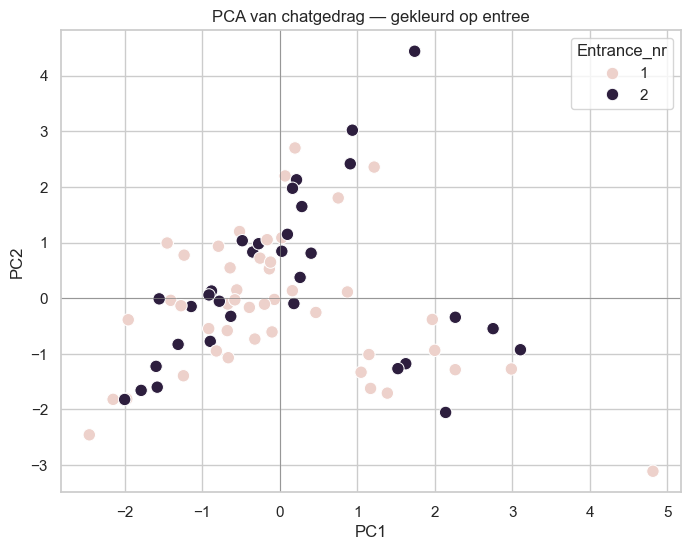

In [39]:
# 8.1 Kleur op entree
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=full_df,
    x="PC1",
    y="PC2",
    hue="Entrance_nr",
    s=80
)

plt.title("PCA van chatgedrag — gekleurd op entree")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.show()


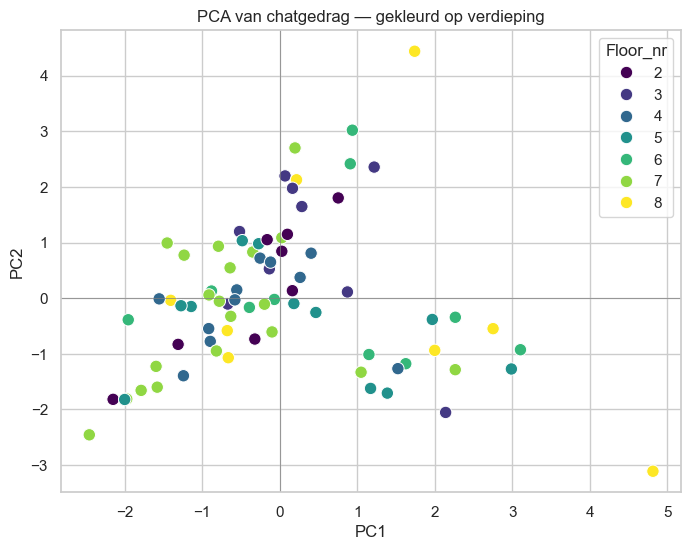

In [41]:
# 8.2 Alternatief: kleur op verdieping
# 8.1 Kleur op entree
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=full_df,
    x="PC1",
    y="PC2",
    hue="Floor_nr",
    palette="viridis",
    s=80
)

plt.title("PCA van chatgedrag — gekleurd op verdieping")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.show()


### 🔹 Stap 9 – (Optioneel) t-SNE voor niet-lineaire structuur

In [42]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

full_df["TSNE1"] = X_tsne[:, 0]
full_df["TSNE2"] = X_tsne[:, 1]


<Axes: xlabel='TSNE1', ylabel='TSNE2'>

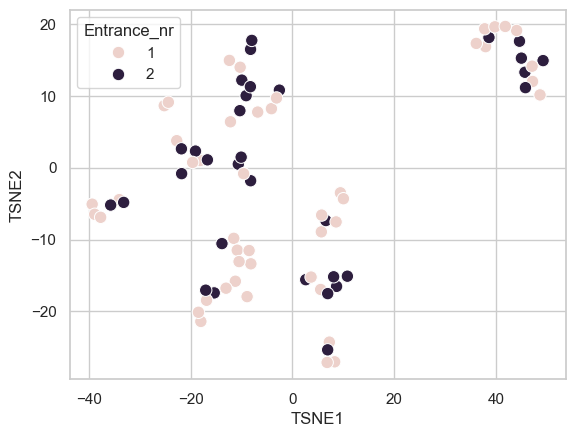

In [43]:
sns.scatterplot(
    data=full_df,
    x="TSNE1",
    y="TSNE2",
    hue="Entrance_nr",
    s=80
)


### 🔹 Stap 10 – Hoe beschrijf je dit in woorden?

“De PCA-projectie van chatgedrag toont dat de eerste component voornamelijk samenhangt met activiteit en informatiedichtheid, terwijl de tweede component een onderscheid maakt tussen informeel avond-/weekendgebruik en functioneler gebruik overdag. Bij inkleuring op entree is sprake van lichte groepering, maar met aanzienlijke overlap, wat suggereert dat fysieke nabijheid slechts beperkt samenhangt met online communicatiestijl.”

### 🔹 Stap 11 – Wat is een ‘cluster’ hier?

Een cluster is:

een groep bewoners

die dicht bij elkaar ligt in PCA-ruimte

én dezelfde fysieke kleur deelt (entree/verdieping)

✅ Wat je nu hebt

- ✔️ Reproduceerbare pipeline
- ✔️ Methodologisch correct
- ✔️ Goed uitlegbaar in verslag/presentatie
- ✔️ Klaar voor uitbreiding (Manhattan distance, clustering-algoritmes)

### 📏 Manhattan-distance test
- Binnen vs tussen entrees
- We testen dit met Manhattan distance (L1).

#### 🔹 Idee in één zin
Als bewoners uit dezelfde entree vergelijkbaar chatgedrag hebben, dan is hun onderlinge afstand in feature-ruimte gemiddeld kleiner dan de afstand tussen bewoners uit verschillende entrees.

#### 🔹 Waarom Manhattan distance?

Robuuster dan Euclidisch bij:

ratio’s

scheve verdelingen

Sluit goed aan bij gedragsfeatures

Elke feature draagt lineair bij: